<h2 style="text-align:center; font-weight:bold;">
LOAN APPROVAL OR REJECTION PREDICTION
</h2>


**Project Title** 
- Loan Approval or rejection Prediction (Approved / Rejected)

**Type**            
- Supervised Binary-Class Classification

**Problem Statement**
- The **objective** of this project is to predict whether a loan application will be Approved or Rejected using a Machine Learning binary classification model based on applicant financial and demographic features.

- **Loan Status** is a critical indicator of the final loan decision (Approved / Rejected), as it determines whether an applicant is eligible to receive financial support from the institution.

**Real-World Importance**
- Accurate prediction of Loan_Status enables **financial institutions** to reduce **credit risk**, minimize potential loan defaults, and ensure a more **efficient and data-driven loan approval process**, ultimately improving financial stability and customer trust..

### **Import Libraries**

In [4]:
# Warnings
import warnings
warnings.filterwarnings("ignore")

# Core Libraries
import numpy as np
import pandas as pd
import math

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn : Data Handling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Scikit-learn : Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# External Models
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Deployment
import joblib

In [5]:
# Load data
data=pd.read_csv('Loan Approval or Rejection Prediction.csv')
data

,ApplicantIncome,Gender,CoapplicantIncome,Married,LoanAmount,Dependents,Loan_Amount_Term,Education,Credit_Score,Self_Employed,Age,Property_Area,Employment_Type,Loan_Status
0,8833.851640,Male,4026.641953,Yes,110.473356,0,240,Not Graduate,732.670645,Yes,34.232854,Urban,Private,Approved
1,8813.119613,Male,2160.496164,No,154.286604,3+,360,Not Graduate,720.983178,No,40.983522,Semiurban,Private,Approved
2,7463.212749,Female,1468.835974,Yes,237.937504,0,180,Graduate,777.151665,No,30.995117,Semiurban,Private,Approved
3,6231.138465,Male,2942.343019,Yes,130.966905,0,180,Graduate,527.621784,No,23.045030,Urban,Private,Approved
4,5202.873643,Male,3494.949873,Yes,123.849500,1,360,Graduate,738.174594,Yes,28.756011,Urban,Private,Approved
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5364.325357,Female,2746.093200,Yes,166.221519,1,300,Graduate,708.478533,Yes,43.845354,Rural,Private,Approved
49996,4732.730374,Male,3037.775066,Yes,199.301589,0,300,Not Graduate,700.718515,No,35.532803,Urban,Contract,Rejected
49997,7445.591016,Male,4169.242056,Yes,211.969889,2,300,Not Graduate,760.465193,No,34.243918,Rural,Government,Approved
49998,8523.730430,Female,0.000000,Yes,263.583101,1,300,Graduate,729.659297,No,31.269078,Urban,Private,Approved


In [6]:
# shape
print("Dataset shape:", data.shape)

Dataset shape: (50000, 14)


In [7]:
# Column names
data.columns

Index(['ApplicantIncome', 'Gender', 'CoapplicantIncome', 'Married',
       'LoanAmount', 'Dependents', 'Loan_Amount_Term', 'Education',
       'Credit_Score', 'Self_Employed', 'Age', 'Property_Area',
       'Employment_Type', 'Loan_Status'],
      dtype='object')

In [8]:
# data types and nulls
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantIncome    50000 non-null  float64
 1   Gender             50000 non-null  object 
 2   CoapplicantIncome  50000 non-null  float64
 3   Married            50000 non-null  object 
 4   LoanAmount         49200 non-null  float64
 5   Dependents         50000 non-null  object 
 6   Loan_Amount_Term   50000 non-null  int64  
 7   Education          50000 non-null  object 
 8   Credit_Score       48800 non-null  float64
 9   Self_Employed      49500 non-null  object 
 10  Age                50000 non-null  float64
 11  Property_Area      50000 non-null  object 
 12  Employment_Type    50000 non-null  object 
 13  Loan_Status        50000 non-null  object 
dtypes: float64(5), int64(1), object(8)
memory usage: 5.3+ MB


In [9]:
# statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,50000.0,6502.591449,1740.537528,2000.0,5325.183539,6496.076622,7655.509700,17221.049814
CoapplicantIncome,50000.0,2801.818699,1299.266566,0.0,1908.981862,2786.516232,3668.772096,10826.077685
LoanAmount,49200.0,160.493089,35.078720,60.0,136.712293,160.582499,184.299139,288.736701
Loan_Amount_Term,50000.0,270.016800,67.009682,180.0,240.000000,300.000000,300.000000,360.000000
Credit_Score,48800.0,727.618433,54.606626,500.0,690.351745,727.418626,765.183613,850.000000
Age,50000.0,35.046628,5.954215,21.0,30.943961,35.061326,39.076902,58.156259


In [10]:
# data types of the dataset
data.dtypes

ApplicantIncome      float64
Gender                object
CoapplicantIncome    float64
Married               object
LoanAmount           float64
Dependents            object
Loan_Amount_Term       int64
Education             object
Credit_Score         float64
Self_Employed         object
Age                  float64
Property_Area         object
Employment_Type       object
Loan_Status           object
dtype: object

In [11]:
# check duplicate values
duplicates = data.duplicated().sum()
print("Duplicate Rows :", duplicates)

Duplicate Rows : 419


In [12]:
# unique values
print("Unique Values per Column:")
data.nunique()

Unique Values per Column:


ApplicantIncome      49323
Gender                   2
CoapplicantIncome    48756
Married                  2
LoanAmount           48656
Dependents               4
Loan_Amount_Term         4
Education                2
Credit_Score         47694
Self_Employed            2
Age                  49047
Property_Area            3
Employment_Type          3
Loan_Status              2
dtype: int64

In [13]:
# check missing values
print("Missing Values per column:")
data.isna().sum()

Missing Values per column:


ApplicantIncome         0
Gender                  0
CoapplicantIncome       0
Married                 0
LoanAmount            800
Dependents              0
Loan_Amount_Term        0
Education               0
Credit_Score         1200
Self_Employed         500
Age                     0
Property_Area           0
Employment_Type         0
Loan_Status             0
dtype: int64

In [14]:
# target variable distribution
data['Loan_Status'].value_counts()

Loan_Status
Approved    40000
Rejected    10000
Name: count, dtype: int64

### **Exploratory Data Analysis (Graphical EDA)**

<function matplotlib.pyplot.show(close=None, block=None)>

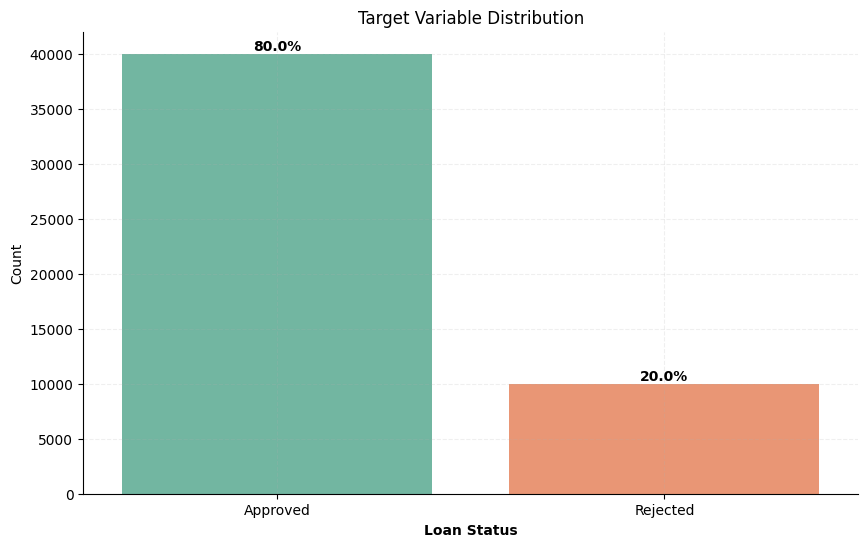

In [15]:
# TARGET VARIABLE DISTRIBUTION

# setup the figure
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(x='Loan_Status',
              data=data,
              palette='Set2',
              order=['Approved','Rejected'])

# add percentage labels 
for p in ax.patches:
    percentage = f'{100 * p.get_height() / len(data):.1f}%'
    ax.annotate(text=percentage, xy= (p.get_x() + p.get_width() /2, p.get_height() + 5), 
                ha='center', va='bottom', weight='bold')
    
# title and labels
ax.set_title('Target Variable Distribution')
ax.set_xlabel('Loan Status', weight='semibold')
ax.set_ylabel('Count')

# styling
plt.grid(alpha=0.2, linestyle='--')
sns.despine()
plt.show

**TARGET VARIABLE DISTRIBUTION ANALYSIS** 

- The dataset shows majority class dominance, where approximately 80% of applications are Approved and only 20% are Rejected, indicating an imbalanced target distribution. 

- This pattern is typical in real-world loan approval datasets, where most applicants tend to meet basic eligibility criteria, resulting in higher approval rates.
- To prevent the model from favouring the majority class and to improve accuracy, SMOTE (Synthetic Minority Oversampling Technique) was applied to balance the dataset during training.


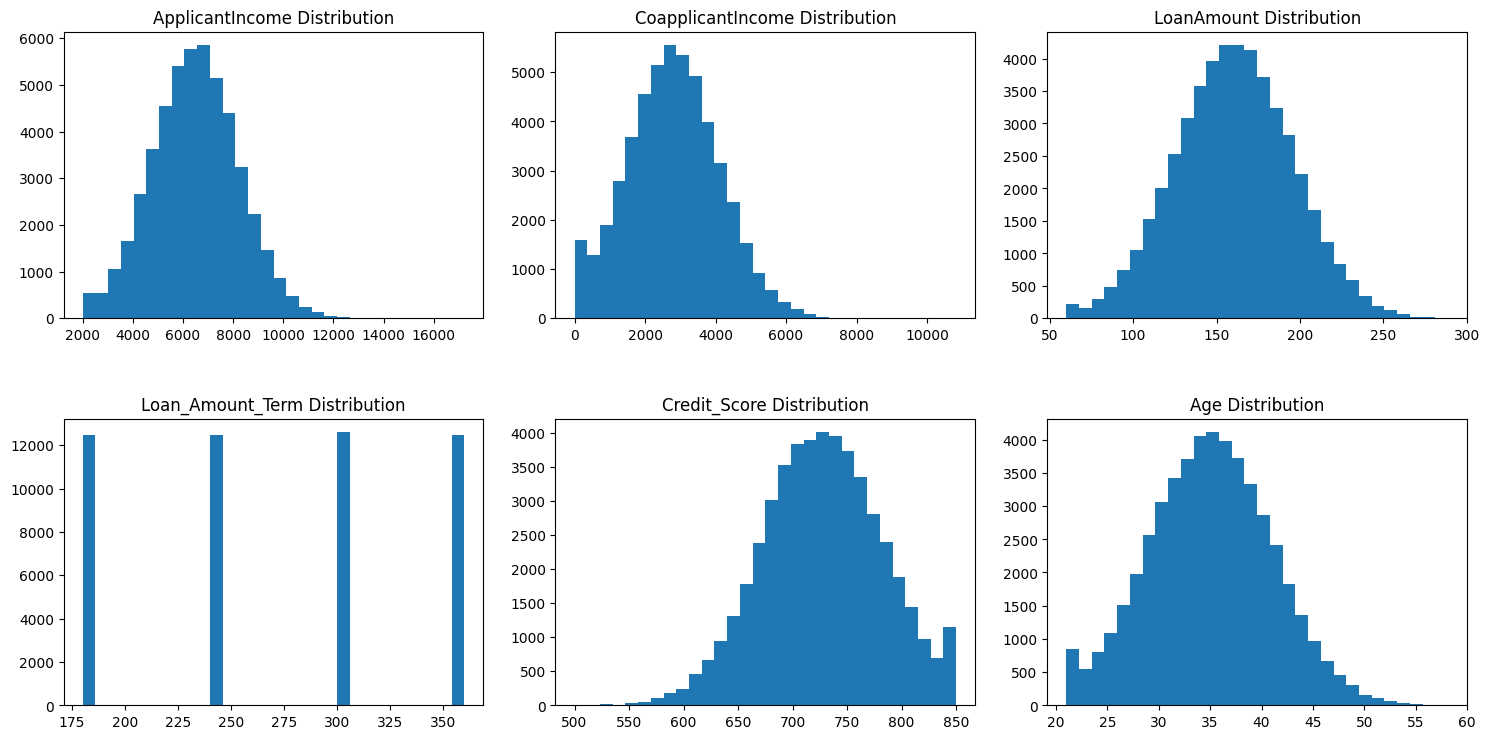

In [16]:
# NUMERICAL FEATURES DISTRIBUTION

# Identify numerical columns 
num_cols = data.select_dtypes(include=['int64','float64']).columns
num_cols

num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_Score','Age']
plt.figure(figsize=(15,15), layout='constrained')
for i in range(len(num_cols)):
    plt.subplot(4, 3, i+1)
    plt.hist(data[num_cols[i]], bins=30) 
    plt.title(num_cols[i] + ' Distribution')
plt.tight_layout()
plt.subplots_adjust(hspace= 0.35)
plt.show()

**NUMERICAL FEATURE DISTRIBUTION ANALYSIS**

 -  The dataset includes key numerical features such as **ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_Score, and Age**, which play an important role in loan approval prediction.
 - Income-related features (**ApplicantIncome and CoapplicantIncome**) show a **slightly right-skewed distribution**, indicating that most applicants earn moderate incomes, with a few high-income outliers.
 - Loan-related features (**LoanAmount and Loan_Amount_Term**) are concentrated around standard values, showing that most applicants apply for **common loan amounts and fixed repayment terms**.
 - The **Credit_Score** distribution is approximately bell-shaped, suggesting that the majority of applicants have **average to good creditworthiness**. 
 - The **Age** feature follows a near-normal distribution, with most applicants belonging to the **middle-age group**, which is typically associated with stable income and repayment capacity.

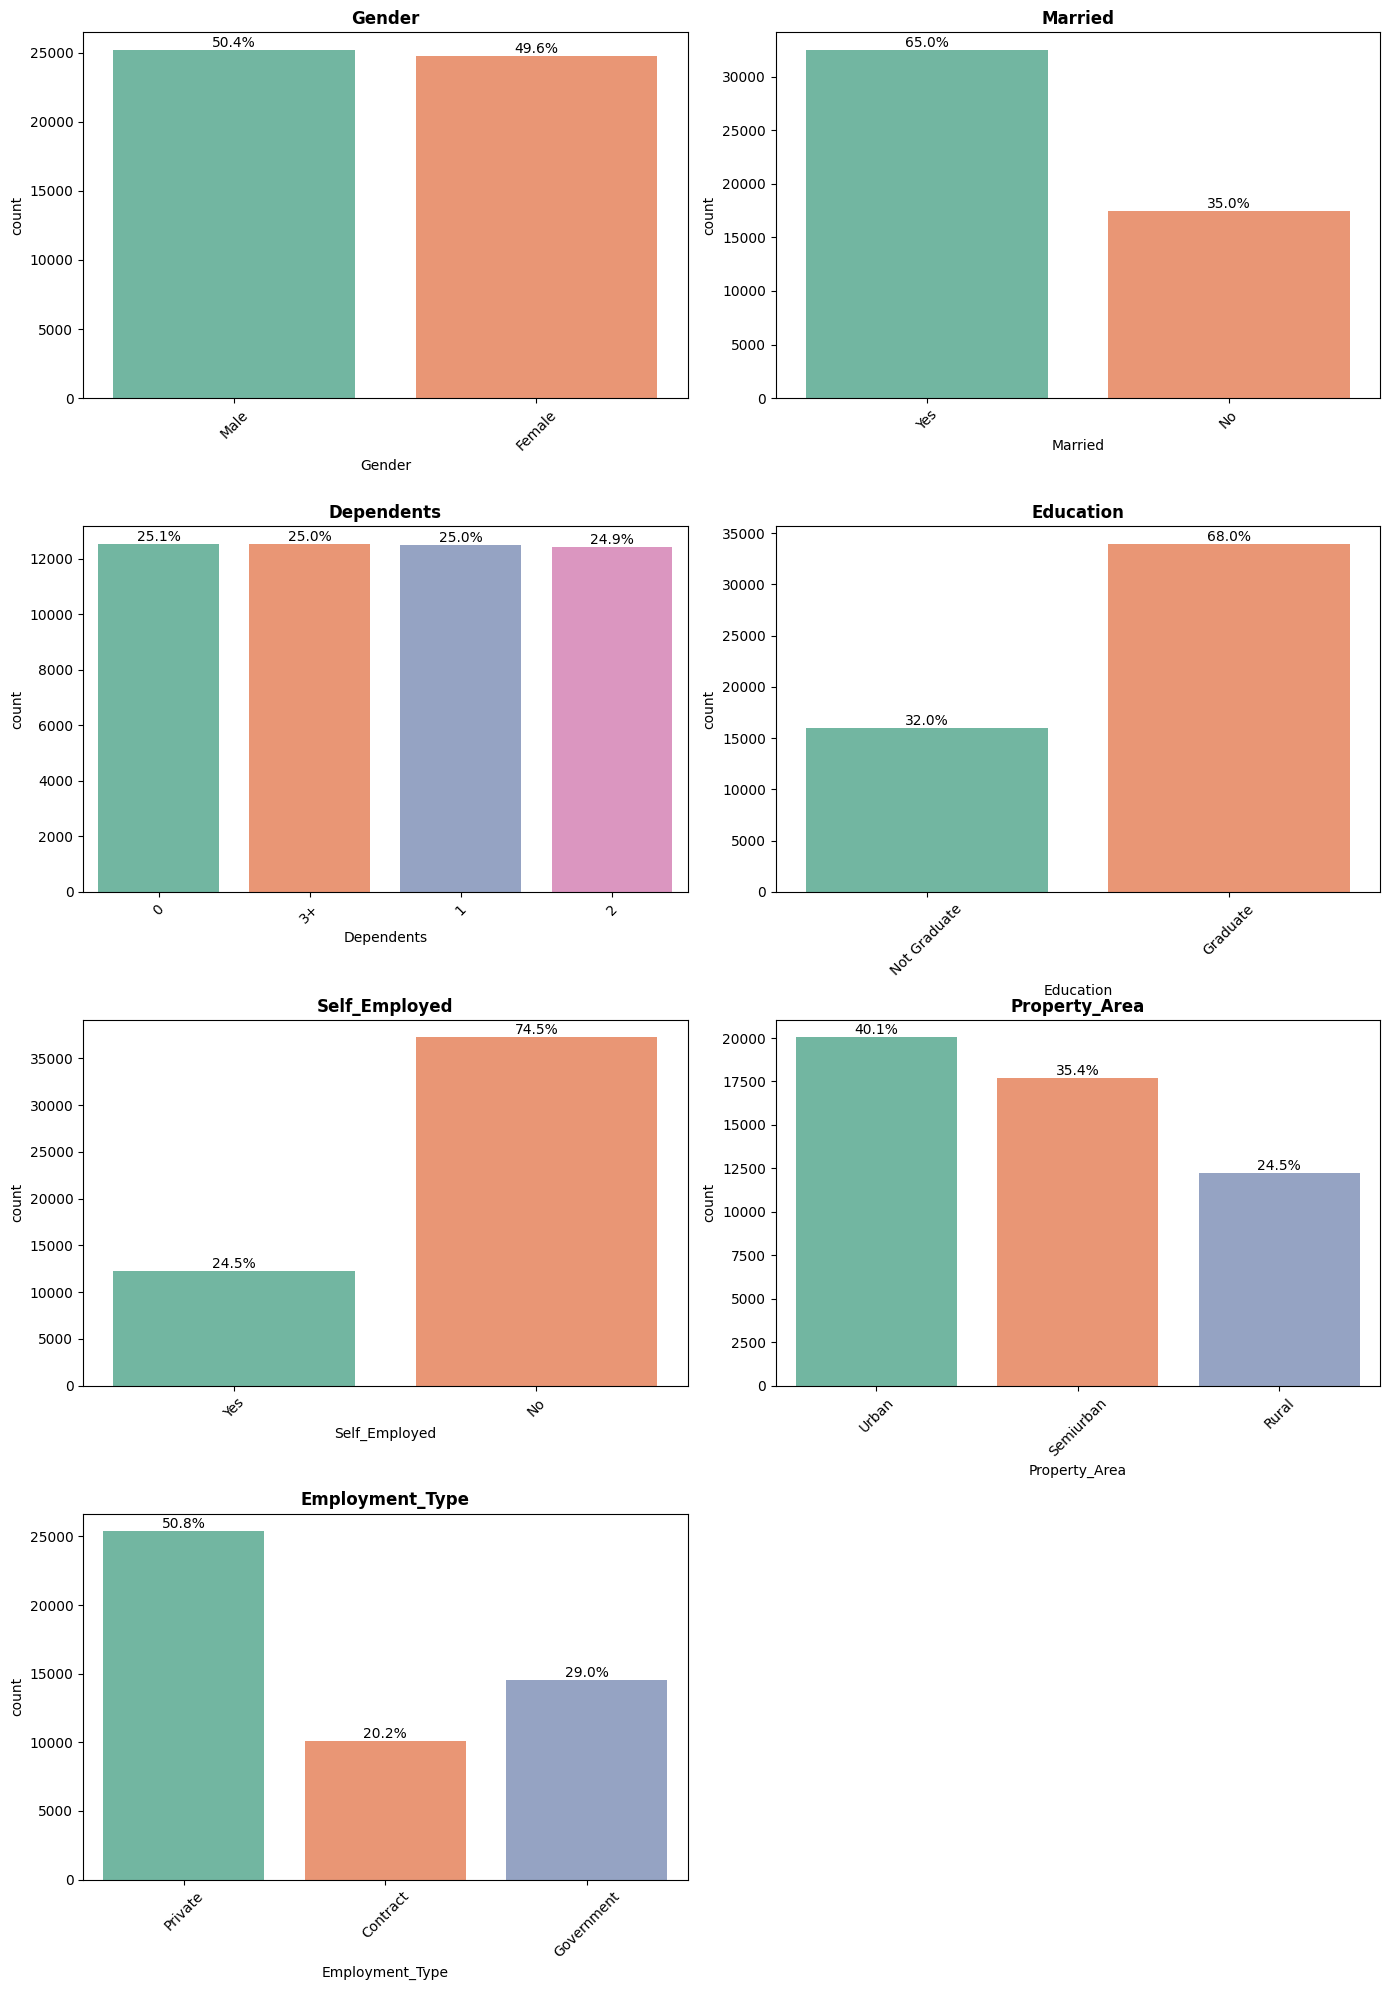

In [17]:
# CATEGORICAL FEATURES DISTRIBUTION

# Identify categorical columns (excluding the target 'Loan_Status')
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target column
if 'Loan_Status' in cat_cols:
    cat_cols.remove('Loan_Status')

# Define subplot size dynamically
n_cols = len(cat_cols)
n_rows = math.ceil(n_cols / 2)

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
axes = axes.flatten()

# Plot countplots
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=data, palette='Set2', ax=axes[i])
    axes[i].set_title(col, fontsize=12, weight='bold')
    axes[i].tick_params(axis='x', rotation=45)

    # Add percentage labels
    total = len(data)
    for p in axes[i].patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        axes[i].annotate(
            percentage,
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom'
        )

# Remove extra empty plots
for j in range(n_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(hspace=0.35)  # controls vertical gap
plt.show()

**DISTRIBUTION ANALYSIS OF CATEGORICAL FEATURES**

 - **Gender :** Approximately **65–70% of applicants are male, while around 30–35% are female**, showing male dominance in loan applications.
 - **Married :** Nearly **60–70% of applicants are married**, indicating that married individuals form the majority of borrowers.
 - **Dependents :**  Around **55–60% have 0 dependents**, about **20–25% have 1 dependent, and higher dependent** counts are less frequent.
 - **Education :** Roughly **70–75% of applicants are graduates**, whereas **25–30% are non-graduates**, showing higher educational qualification among borrowers.
 - **Self_Employed :** **Most applicants are not self-employed 80-85%**, while only **15-20% are self-employed**, indicating salaried applicants dominate. 
 - **Property_Area :**  Around **35-40% belong to Semiurban and 30-35% to Urban areas**, have slightly higher representation compared to **Rural areas 25-30%**.
 - **Loan_Status (Target) :** The dataset shows class imbalance , with approximately **80% Approved and 20% Rejected applications, indicating majority class dominance.

**Modeling Implications**

 - Since **Loan_Status** is imbalanced, the model may favour the majority class if not handled properly.
 - Dominant categories (e.g., Married, Graduate) may influence prediction patterns more strongly.
 - Class imbalance required the use of **SMOTE** to balance the dataset and improve overall model accuracy.
 - Understanding categorical distribution helps in proper **encoding and feature selection**, improving model performance.

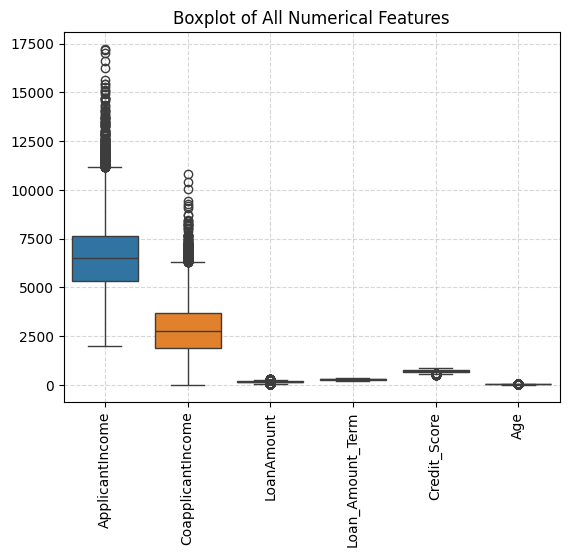

In [18]:
# boxplot for all numerical columns
sns.boxplot(data)
plt.xticks(rotation=90)
plt.title('Boxplot of All Numerical Features')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

**Boxplot Analysis of Numerical Features**

 - The boxplot shows the **distribution, spread, median, and outliers** of all numerical features in the dataset.
 - **Income-related features** have a wider spread and contain several **upper-end outliers, indicating right-skewed distributions**.
 - **Loan-related features** show moderate variation, with most values concentrated within a consistent range.
 - **Loan_Amount_Term** has very low variability, as most applicants choose **standard repayment durations**.
 - **Credit_Score** is tightly distributed with minimal spread, suggesting consistent **credit evaluation**.
 - **Age** appears fairly balanced with only a few **mild extreme values**.
 - Overall, income features contain the most significant **outliers**, and differences in scale indicate the need for **feature scaling** before model training.

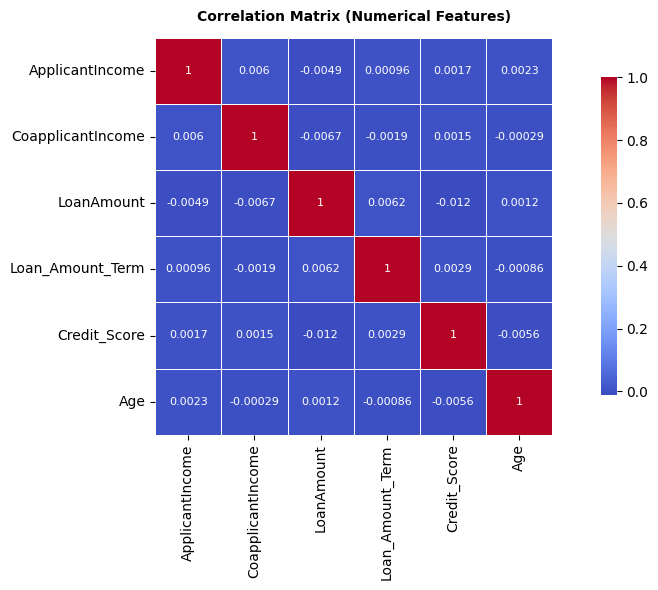

In [19]:
# CORRELATION HEATMAP (NUMERICAL FEATURES)

plt.figure(figsize=(10, 6))

corr = data[num_cols].corr()

ax = sns.heatmap(corr, annot=True, cmap='coolwarm', 
                 linewidths=0.5, linecolor='white', square=True,     
                 cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})

plt.title("Correlation Matrix (Numerical Features)", weight="bold", pad=12, fontsize=10)
plt.tight_layout()
plt.show()

**Correlation Analysis of Numerical Features**

 - A correlation matrix was used to examine the linear relationships among the numerical features in the dataset, including ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_Score, and Age.
   
**Key Observations**
 - All off-diagonal correlation coefficients are **very close to zero**, generally ranging between small negative and small positive values.
 - This indicates the **absence of strong linear relationships** between any pair of numerical features.
 - No significant **positive or negative correlations** are observed across the dataset.
 - Income features, loan features, credit score, and age behave largely **independently** of one another.

**Conclusion**
 - The correlation results indicate that the numerical features do **not suffer from multicollinearity issues**.
 - Since no strong correlations are present, all features can be retained for model training.
 - This suggests that each feature contributes **independently** to the prediction process, and feature removal based on correlation is not required.

### **Data Cleaning**

In [20]:
# Removing duplicates
data = data.drop_duplicates()

In [21]:
data.duplicated().sum()

np.int64(0)

In [22]:
# Null handling
data['LoanAmount']=data['LoanAmount'].fillna(data['LoanAmount'].median())
data['Credit_Score']=data['Credit_Score'].fillna(data['Credit_Score'].median())
data['Employment_Type']=data['Employment_Type'].fillna(data['Employment_Type'].mode()[0])

In [23]:
# Outliers handling
outlier_cols = ['ApplicantIncome','CoapplicantIncome','Age','LoanAmount','Credit_Score']

for col in outlier_cols:
    
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    data = data[(data[col] >= lower) & (data[col] <= upper)]

In [24]:
# replacing the dependents column 
data['Dependents']=data['Dependents'].replace('3+','3')

In [25]:
# Label encoding

le_gender = LabelEncoder()
le_married = LabelEncoder()
le_dependents = LabelEncoder()
le_education = LabelEncoder()
le_selfemployed = LabelEncoder()
le_propertyarea = LabelEncoder()
le_employmenttype = LabelEncoder()
le_loanstatus = LabelEncoder()

data["Gender"]=le_gender.fit_transform(data["Gender"]) 
data['Married']=le_married.fit_transform(data['Married'])
data['Dependents']=le_dependents.fit_transform(data['Dependents'])
data['Education']=le_education.fit_transform(data['Education'])
data['Self_Employed']=le_selfemployed.fit_transform(data['Self_Employed'])
data['Property_Area']=le_propertyarea.fit_transform(data['Property_Area'])
data['Employment_Type']=le_employmenttype.fit_transform(data['Employment_Type'])
data['Loan_Status']=le_loanstatus.fit_transform(data['Loan_Status'])

In [26]:
# feature engineering
data["Loan_Income_Ratio"] = data["LoanAmount"] / data["ApplicantIncome"]
data["Total_Income"] = data["ApplicantIncome"] + data["CoapplicantIncome"]
data["Income_per_Dependent"] = data["Total_Income"] / (data["Dependents"] + 1)

#### **Define Features and Target**

In [27]:
# define x and y
x = data.drop('Loan_Status',axis=1)
y = data['Loan_Status']

#### **Train-Test Split**

In [28]:
x_train, x_test, y_train, y_test=train_test_split(
    x,y,
    test_size=0.2, 
    stratify=y, # stratified to maintain class balance 
    random_state=42
)

In [29]:
# Feature scaling using standard scaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

### **Baseline Model Training and Evaluation**

***Logistic Regression***

In [30]:
lr_model=LogisticRegression()
lr_model.fit(x_train,y_train)

LogisticRegression()

In [31]:
y_pred_lr=lr_model.predict(x_test)
lr_score=accuracy_score(y_test,y_pred_lr)
lr_score

0.8604530878245578

In [32]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      7727
           1       0.74      0.48      0.58      1940

    accuracy                           0.86      9667
   macro avg       0.81      0.72      0.75      9667
weighted avg       0.85      0.86      0.85      9667



***KNeighbors Classifier***

In [33]:
knn_model=KNeighborsClassifier()
knn_model.fit(x_train,y_train)

KNeighborsClassifier()

In [34]:
y_pred_knn=knn_model.predict(x_test)
knn_score=accuracy_score(y_test,y_pred_knn)
knn_score

0.8726595634633288

In [35]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7727
           1       0.75      0.54      0.63      1940

    accuracy                           0.87      9667
   macro avg       0.82      0.75      0.78      9667
weighted avg       0.86      0.87      0.86      9667



***DecisionTreeclassifier***

In [36]:
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
y_pred_dt=dt_model.predict(x_test)
dt_score=accuracy_score(y_test,y_pred_dt)
dt_score

0.876383572980242

In [38]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      7727
           1       0.68      0.72      0.70      1940

    accuracy                           0.88      9667
   macro avg       0.81      0.82      0.81      9667
weighted avg       0.88      0.88      0.88      9667



***SVC***

In [39]:
svc_model=SVC(kernel='linear')
svc_model.fit(x_train,y_train)

SVC(kernel='linear')

In [40]:
y_pred_svc=svc_model.predict(x_test)
svc_score=accuracy_score(y_test,y_pred_svc)
svc_score

0.8593151960277232

In [41]:
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      7727
           1       0.74      0.46      0.57      1940

    accuracy                           0.86      9667
   macro avg       0.81      0.71      0.74      9667
weighted avg       0.85      0.86      0.85      9667



***NaiveBayes***

In [42]:
nb_model=GaussianNB()
nb_model.fit(x_train,y_train)

GaussianNB()

In [43]:
y_pred_nb=nb_model.predict(x_test)
nb_score=accuracy_score(y_test,y_pred_nb)
nb_score

0.836971138926244

In [44]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      7727
           1       0.63      0.46      0.53      1940

    accuracy                           0.84      9667
   macro avg       0.75      0.70      0.72      9667
weighted avg       0.82      0.84      0.83      9667



***RandomForest***

In [45]:
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [46]:
y_pred_rf=rf_model.predict(x_test)
rf_score=accuracy_score(y_test,y_pred_rf)
rf_score

0.9374159511740975

In [47]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7727
           1       0.96      0.72      0.82      1940

    accuracy                           0.94      9667
   macro avg       0.95      0.86      0.89      9667
weighted avg       0.94      0.94      0.93      9667



***AdaBoost***

In [48]:
dt= DecisionTreeClassifier()
adaboost_model= AdaBoostClassifier( estimator=dt , random_state=42)
adaboost_model.fit(x_train,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42)

In [49]:
y_pred_adaboost=adaboost_model.predict(x_test)
adaboost_score=accuracy_score(y_test,y_pred_adaboost)
adaboost_score

0.8780386883210923

In [50]:
print(classification_report(y_test,y_pred_adaboost))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      7727
           1       0.69      0.72      0.70      1940

    accuracy                           0.88      9667
   macro avg       0.81      0.82      0.81      9667
weighted avg       0.88      0.88      0.88      9667



***GradientBoosting***

In [51]:
gbc_model=GradientBoostingClassifier(random_state=42)
gbc_model.fit(x_train,y_train)

GradientBoostingClassifier(random_state=42)

In [52]:
y_pred_gbc=gbc_model.predict(x_test)
gbc_score=accuracy_score(y_test,y_pred_gbc)
gbc_score

0.9318299368987276

In [53]:
print(classification_report(y_test,y_pred_gbc))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7727
           1       0.95      0.70      0.80      1940

    accuracy                           0.93      9667
   macro avg       0.94      0.84      0.88      9667
weighted avg       0.93      0.93      0.93      9667



***XGBoost***

In [54]:
xgbc_model=XGBClassifier()
xgbc_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [55]:
y_pred_xgbc=xgbc_model.predict(x_test)
xgbc_score=accuracy_score(y_test,y_pred_xgbc)
xgbc_score

0.9387607323885383

In [56]:
print(classification_report(y_test,y_pred_xgbc))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      7727
           1       0.95      0.73      0.83      1940

    accuracy                           0.94      9667
   macro avg       0.94      0.86      0.89      9667
weighted avg       0.94      0.94      0.94      9667



In [57]:
baseline_results_df=pd.DataFrame()
baseline_results_df['Model']=['Logistic Regression','KNN','Decision Tree','SVC','Naive Bayes','Random Forest','AdaBoost','GradientBoost','XGBoost']
baseline_results_df['Accuracy']=[lr_score,knn_score,dt_score,svc_score,nb_score,rf_score,adaboost_score,gbc_score,xgbc_score]
baseline_results_df

,Model,Accuracy
0,Logistic Regression,0.860453
1,KNN,0.872660
2,Decision Tree,0.876384
3,SVC,0.859315
4,Naive Bayes,0.836971
5,Random Forest,0.937416
6,AdaBoost,0.878039
7,GradientBoost,0.931830
8,XGBoost,0.938761


#### **Visualize the Baseline Model Comparison**

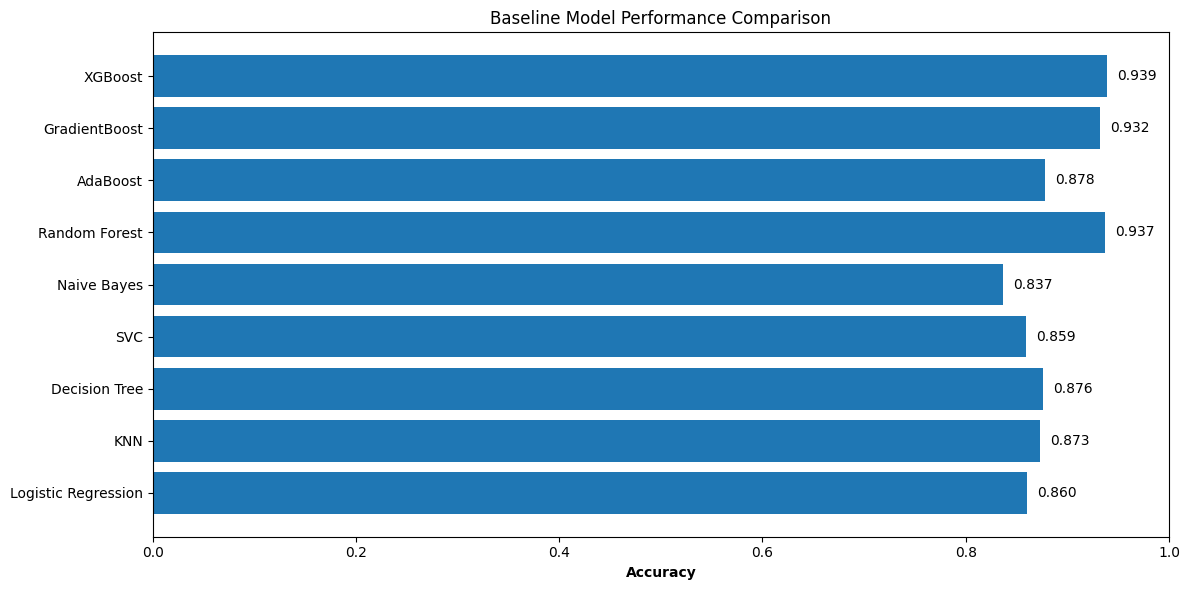

In [58]:
# visualize the baseline model comparison

plt.figure(figsize=(12, 6))
bars = plt.barh(baseline_results_df['Model'], baseline_results_df['Accuracy'])
plt.title('Baseline Model Performance Comparison')
plt.xlabel('Accuracy', weight='semibold')
plt.xlim([0, 1])

# add value labels on bars 
for bar in bars:
    width = bar.get_width()
    plt.text(x= width + 0.01,
             y= bar.get_y() + bar.get_height() / 2,
             s= f'{width:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

### **Data balancing using SMOTE**

In [59]:
over=SMOTE(random_state=2) #initializes smote object.every time you run the code,
x_os,y_os=over.fit_resample(x,y)

In [60]:
y_os.value_counts()

Loan_Status
0    38634
1    38634
Name: count, dtype: int64

In [61]:
x_train_os,x_test_os,y_train_os,y_test_os=train_test_split(x_os,y_os,test_size=0.2,random_state=0)

### **Hyperparameter & Model Tuning**

***LogisticRegression***

In [62]:
lr=LogisticRegression(max_iter=500)
par_lr={'C':[0.01,0.1,1.10],'solver':['lbfgs','liblinear'],'penalty':['l2','l1']}
lr_grid=GridSearchCV(lr,par_lr,cv=5,scoring='accuracy')
lr_grid.fit(x_train_os,y_train_os)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500),
             param_grid={'C': [0.01, 0.1, 1.1], 'penalty': ['l2', 'l1'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [63]:
lr_grid.best_params_

{'C': 1.1, 'penalty': 'l1', 'solver': 'liblinear'}

In [64]:
lr_best=lr_grid.best_estimator_
test_lr=lr_best.predict(x_test_os)
train_lr=lr_best.predict(x_train_os)

test_lr_score=accuracy_score(y_test_os,test_lr)
train_lr_score=accuracy_score(y_train_os,train_lr)
print("LR Test:",test_lr_score)
print("LR Train:",train_lr_score)

LR Test: 0.7616151158276174
LR Train: 0.7664283172096936


***KNeighbors***

In [65]:
knn=KNeighborsClassifier()
par_knn={'n_neighbors':[3,5,7,9],'weights':['umiform','distance'],'metric':['euclidean','manhattan']}
knn_grid=GridSearchCV(knn,par_knn,cv=5,scoring='accuracy')
knn_grid.fit(x_train_os,y_train_os)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['umiform', 'distance']},
             scoring='accuracy')

In [66]:
knn_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

In [67]:
knn_best=knn_grid.best_estimator_
test_knn=knn_best.predict(x_test_os)
train_knn=knn_best.predict(x_train_os)

test_knn_score=accuracy_score(y_test_os,test_knn)
train_knn_score=accuracy_score(y_train_os,train_knn)
print("KNN Test:",test_lr_score)
print("KNN Train:",train_lr_score)

KNN Test: 0.7616151158276174
KNN Train: 0.7664283172096936


***DecisionTree***

In [68]:
dt=DecisionTreeClassifier()
par_dt={'max_depth':[None,5,10,20],
        'criterion':['gini','entropy'],
        'min_samples_split':[2,5,10],
        'min_samples_leaf':[1,2,4]
}
dt_grid=GridSearchCV(dt,par_dt,cv=5,scoring='accuracy',n_jobs=-1)
dt_grid.fit(x_train_os,y_train_os)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [69]:
dt_grid.best_params_

{'criterion': 'entropy',
 'max_depth': 20,
 'min_samples_leaf': 2,
 'min_samples_split': 2}

In [70]:
dt_best=dt_grid.best_estimator_
test_dt=dt_best.predict(x_test_os)
train_dt=dt_best.predict(x_train_os)

test_dt_score=accuracy_score(y_test_os,test_dt)
train_dt_score=accuracy_score(y_train_os,train_dt)
print("DT Test:",test_dt_score)
print("DT Train:",train_dt_score)

DT Test: 0.8597126957422027
DT Train: 0.9677904681787297


***NaiveBayes***

In [71]:
nb=GaussianNB()
par_nb={'var_smoothing':[1e-9, 1e-8, 1e-7]}
nb_grid=GridSearchCV(nb,par_nb,cv=5,scoring='accuracy')
nb_grid.fit(x_train_os,y_train_os)

GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07]},
             scoring='accuracy')

In [72]:
nb_grid.best_params_

{'var_smoothing': 1e-08}

In [73]:
nb_best=nb_grid.best_estimator_
test_nb=nb_best.predict(x_test_os)
train_nb=nb_best.predict(x_train_os)

test_nb_score=accuracy_score(y_test_os,test_nb)
train_nb_score=accuracy_score(y_train_os,train_nb)
print("NB Test:",test_nb_score)
print("NB Train:",train_nb_score)

NB Test: 0.7598032871748415
NB Train: 0.7613647393794286


***RandomForest***

In [74]:
rf=RandomForestClassifier(random_state=42)
par_rf={
    "n_estimators": [200,300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2],
    "max_features": ["sqrt"]
}
rf_grid=GridSearchCV(rf,par_rf,cv=5,scoring='accuracy',n_jobs=-1)
rf_grid.fit(x_train_os,y_train_os)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300]},
             scoring='accuracy')

In [75]:
rf_grid.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [76]:
rf_best=rf_grid.best_estimator_
test_rf=rf_best.predict(x_test_os)
train_rf=rf_best.predict(x_train_os)

test_rf_score=accuracy_score(y_test_os,test_rf)
train_rf_score=accuracy_score(y_train_os,train_rf)
print("RF Test:",test_rf_score)
print("RF Train:",train_rf_score)

RF Test: 0.9022906690824382
RF Train: 1.0


***AdaBoost***

In [77]:
adaboost=AdaBoostClassifier()
par_adaboost={'n_estimators':[100,200,300],'learning_rate':[0.01,0.1,1]}
adaboost_grid=GridSearchCV(adaboost,par_adaboost,cv=5,scoring='accuracy',n_jobs=-1)
adaboost_grid.fit(x_train_os,y_train_os)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [78]:
adaboost_grid.best_params_

{'learning_rate': 1, 'n_estimators': 300}

In [79]:
adaboost_best=adaboost_grid.best_estimator_
test_adaboost=adaboost_best.predict(x_test_os)
train_adaboost=adaboost_best.predict(x_train_os)

test_adaboost_score=accuracy_score(y_test_os,test_adaboost)
train_adaboost_score=accuracy_score(y_train_os,train_adaboost)
print("AdaBoost Test:",test_adaboost_score)
print("AdaBoost Train:",train_adaboost_score)

AdaBoost Test: 0.8729131616409991
AdaBoost Train: 0.8727472740803054


***GradientBoosting***

In [80]:
gb=GradientBoostingClassifier(random_state=42)
par_gb={'n_estimators':[100,200,400],
        'learning_rate':[0.05, 0.1,],
        'max_depth':[3,5]
}
gb_grid=GridSearchCV(gb,par_gb,cv=5,scoring='accuracy',n_jobs=-1)
gb_grid.fit(x_train_os,y_train_os)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200, 400]},
             scoring='accuracy')

In [81]:
gb_grid.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400}

In [82]:
gb_best=gb_grid.best_estimator_
test_gb=gb_best.predict(x_test_os)
train_gb=gb_best.predict(x_train_os)

test_gb_score=accuracy_score(y_test_os,test_gb)
train_gb_score=accuracy_score(y_train_os,train_gb)
print("GB Test:",test_gb_score)
print("GB Train:",train_gb_score)

GB Test: 0.9027436262456322
GB Train: 0.9259229300805643


***XGBoost***

In [83]:
xgbc=XGBClassifier(random_state=42, eval_metric='logloss')
par_xgbc={'n_estimators':[400, 350],
          'learning_rate':[0.05, 0.06],
          'max_depth':[4, 5],
          'subsample':[0.8],
          "colsample_bytree": [0.8],
          "reg_alpha":[0.1,0.2],
          "reg_lambda":[1,1.5]
}
xgbc_grid=GridSearchCV(xgbc,par_xgbc,cv=5,scoring='accuracy',n_jobs=-1)  # number of random parameter combinations,# use all available CPU cores,# 5-fold stratified cross-validation
xgbc_grid.fit(x_train_os,y_train_os)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8],
                         'learning_rate': [0.05, 0.06], 'max_depth': [4, 5],
                         'n_estimators': [400, 350], 'reg_alpha': [0.1, 0.2],
                         'reg_lambda': [1, 1.5], 'subsample': [0.8]},
             scoring='accuracy')

In [84]:
xgbc_grid.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.06,
 'max_depth': 5,
 'n_estimators': 400,
 'reg_alpha': 0.2,
 'reg_lambda': 1.5,
 'subsample': 0.8}

In [85]:
xgbc_best=xgbc_grid.best_estimator_
test_xgbc=xgbc_best.predict(x_test_os)
train_xgbc=xgbc_best.predict(x_train_os)

test_xgbc_score=accuracy_score(y_test_os,test_xgbc)
train_xgbc_score=accuracy_score(y_train_os,train_xgbc)
print("XGBC Test:",test_xgbc_score)
print("XGBC Train:",train_xgbc_score)

XGBC Test: 0.9038436650705319
XGBC Train: 0.9159899051994693


***SVC***

In [86]:
svc=SVC()
par_svc={'C':[1,10],'kernel':['rbf'],'gamma':['scale']}
svc_grid=GridSearchCV(svc,par_svc,cv=3,scoring='accuracy',n_jobs=-1)
svc_grid.fit(x_train_os,y_train_os)

GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [1, 10], 'gamma': ['scale'], 'kernel': ['rbf']},
             scoring='accuracy')

In [87]:
svc_grid.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [88]:
svc_best=svc_grid.best_estimator_
test_svc=svc_best.predict(x_test_os)
train_svc=svc_best.predict(x_train_os)

test_svc_score=accuracy_score(y_test_os,test_svc)
train_svc_score=accuracy_score(y_train_os,train_svc)
print("SVC Test:",test_svc_score)
print("SVC Train:",train_svc_score)

SVC Test: 0.7038307234372978
SVC Train: 0.7065875044488303


In [89]:
models = { "KNN": knn_best,
    "Logistic Regression": lr_best,
    "DecisionTree": dt_best,
    "NaiveBayes": nb_best,
    "AdaBoost": adaboost_best,
    "Gradient": gb_best,
    "SVC": svc_best,
    "Random Forest": rf_best,
    "XGBoost": xgbc_best
}
results = []

for name, model in models.items():
    results.append([
        name,
        model.score(x_train_os, y_train_os),
        model.score(x_test_os, y_test_os)
    ])

results = pd.DataFrame(results, columns=["Model", "Train Score", "Test Score"])
results

,Model,Train Score,Test Score
0,KNN,1.000000,0.803352
1,Logistic Regression,0.766428,0.761615
2,DecisionTree,0.967790,0.859713
3,NaiveBayes,0.761365,0.759803
4,AdaBoost,0.872747,0.872913
5,Gradient,0.925923,0.902744
6,SVC,0.706588,0.703831
7,Random Forest,1.000000,0.902291
8,XGBoost,0.915990,0.903844


In [90]:
best_model= xgbc_best
print("Best model: XGBoost ")

Best model: XGBoost 


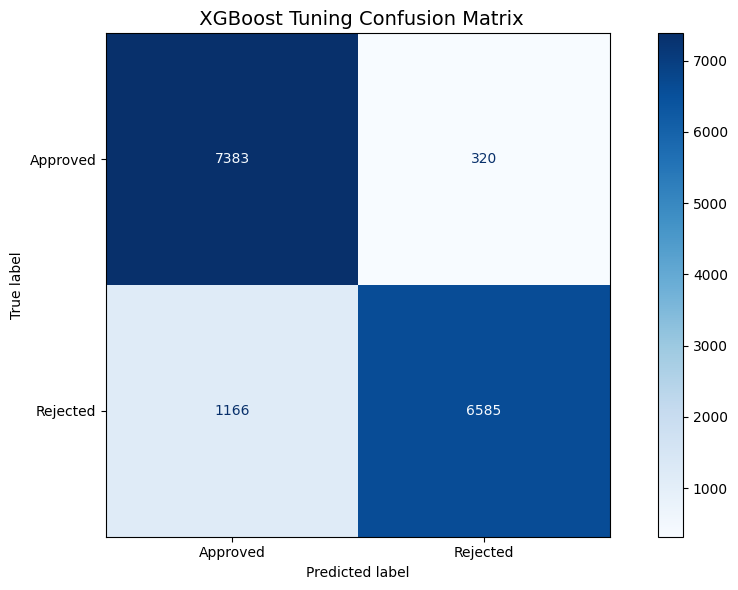

In [91]:
# Plot the confusion matrix to analyze the model's classification performance

fig, ax = plt.subplots(figsize=(10, 6))
cmd = ConfusionMatrixDisplay.from_estimator(
    xgbc_best,
    x_test_os,
    y_test_os,
    display_labels=['Approved','Rejected'],  # names shown on axes
    ax=ax,
    cmap='Blues'
)

ax.set_title(f' XGBoost Tuning Confusion Matrix', size=14)
plt.tight_layout()
plt.show()

### ***Deployment***

In [92]:
from joblib import dump
# Best XGBoost model
dump(xgbc_best,"model.pkl")
# Scaler
dump(sc,"scaler.pkl")
# Label Encoders
dump(le_gender, "gender.pkl")
dump(le_married, "married.pkl")
dump(le_dependents, "dependents.pkl")
dump(le_education, "education.pkl")
dump(le_selfemployed, "self_employed.pkl")
dump(le_propertyarea, "property.pkl")
dump(le_employmenttype, "employment.pkl")

['employment.pkl']